# Modelli di Diffusione: DDPM e DDIM

## Panoramica

Questo notebook implementa e confronta due modelli generativi basati sulla **diffusione**: il **Denoising Diffusion Probabilistic Model (DDPM)** e il **Denoising Diffusion Implicit Model (DDIM)**. Entrambi appartengono alla famiglia dei *score-based generative models*, un paradigma radicalmente diverso da GAN e VAE.

---

## Differenze fondamentali con GAN e VAE

| Caratteristica | GAN | VAE | DDPM / DDIM |
| :--- | :--- | :--- | :--- |
| **Processo generativo** | Una singola rete (generatore) mappa rumore → immagine in un solo passo | Un encoder mappa l'immagine in uno spazio latente; un decoder ricostruisce l'immagine | Una catena di Markov iterativa rimuove progressivamente il rumore in $T$ passi |
| **Training** | Gioco minimax tra generatore e discriminatore (instabile, mode collapse) | Massimizzazione dell'ELBO (Evidence Lower Bound) | Semplice regressione MSE: il modello impara a predire il rumore aggiunto |
| **Stabilità** | Fragile — richiede bilanciamento attento tra G e D | Stabile, ma immagini spesso sfocate | Molto stabile — la loss è una semplice MSE |
| **Qualità** | Alta, ma con rischio di mode collapse | Buona, penalizzata dal blurring | Stato dell'arte — alta fedeltà e diversità |
| **Diversità** | Limitata (mode collapse) | Buona (spazio latente continuo) | Eccellente — il rumore gaussiano copre tutto lo spazio |
| **Costo di inferenza** | Veloce (un solo forward pass) | Veloce (un solo forward pass del decoder) | Lento per DDPM ($T$ passi); **DDIM accelera drasticamente** con passi deterministici |

### DDPM vs DDIM in dettaglio

- **DDPM** (*Ho et al., 2020*): definisce un **processo forward** che aggiunge progressivamente rumore gaussiano all'immagine secondo uno schedule $\beta_t$, e un **processo reverse** stocastico che impara a rimuoverlo. Ogni passo del reverse richiede una valutazione della rete, perciò servono tipicamente $T = 400$–$1000$ passi per generare un'immagine.

- **DDIM** (*Song et al., 2020*): usa lo **stesso modello addestrato con DDPM** ma definisce un processo reverse **deterministico** (non-Markoviano). Questo permette di "saltare" passi intermedi, generando immagini di qualità comparabile con solo $50$–$100$ passi — un'accelerazione di $5$–$10\times$.

### Dataset: Mayo Clinic CT

In questo notebook applichiamo i modelli di diffusione alla generazione di **slice CT** dal dataset Mayo Clinic, ridimensionate a $64 \times 64$ pixel e normalizzate in $[-1, 1]$.


## 1 — Setup, importazioni e preparazione del dataset

Questa cella esegue le seguenti operazioni:

1. **Importazione delle librerie** — PyTorch, torchvision, matplotlib, PIL e tqdm.
2. **Aggiunta di `IPPy` al path** — La libreria locale `IPPy` contiene le utilità specifiche del corso: `get_device()` per selezionare GPU/CPU, e il modulo `nn.diffusion` con l'architettura `DiffusionUNet`, le funzioni di scheduling (`cosine_beta_schedule`), le routine di sampling (`ddpm_sample`, `ddim_sample`), e l'helper `EMA` (Exponential Moving Average).
3. **Definizione di `MayoDataset`** — Un `Dataset` PyTorch che carica le slice CT dal dataset Mayo, le ridimensiona a $64 \times 64$ pixel, le converte in tensori e le normalizza nell'intervallo $[-1, 1]$ (necessario per i modelli di diffusione, che assumono dati centrati sullo zero).
4. **Creazione dei DataLoader** — `train_loader` e `test_loader` con batch size adattato al dispositivo.
5. **Visualizzazione di un batch** — La funzione `show_batch()` denormalizza le immagini e le mostra in una griglia orizzontale.

**Output atteso:** stampa del dispositivo in uso, numero di immagini di training/test, e una riga di slice CT dal training set.


Device: mps
Training images: 3306
Test images: 327
Weights directory: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/weights


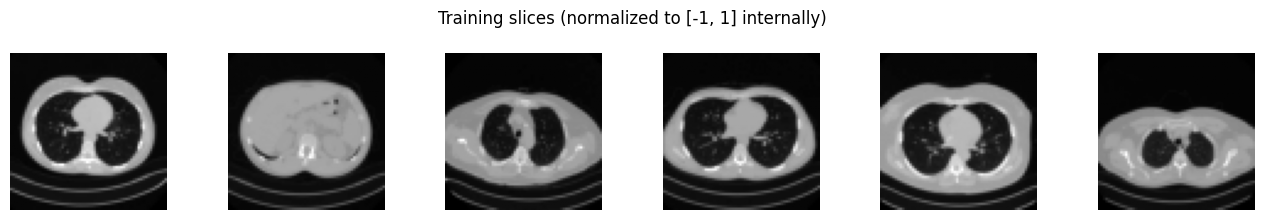

In [1]:
import glob
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

# Imposta la cartella corrente come root del libro, poiché il notebook è già nella radice
book_root = Path('.').resolve()
ipp_root = book_root / 'IPPy'
# Inserisci il percorso in testa a sys.path per dare priorità a IPPy rispetto a moduli omonimi in .venv
if str(ipp_root) not in sys.path:
    sys.path.insert(0, str(ipp_root))

from utilities import get_device
from nn.diffusion import (
    DiffusionUNet,
    EMA,
    cosine_beta_schedule,
    ddim_sample,
    ddpm_sample,
    denormalize_to_01,
    extract,
)

weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)


class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)


device = get_device()
batch_size = 32 if device == 'cuda' else 8
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=64)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=64)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device == 'cuda'),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device == 'cuda'),
)


def show_batch(batch, title, ncols=6):
    images = denormalize_to_01(batch[:ncols]).cpu()
    fig, axes = plt.subplots(1, len(images), figsize=(2.2 * len(images), 2.2))
    axes = axes if len(images) > 1 else [axes]
    for ax, image in zip(axes, images):
        ax.imshow(image.squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


print('Device:', device)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Weights directory:', weights_dir)

sample_batch = next(iter(train_loader))
show_batch(sample_batch, 'Training slices (normalized to [-1, 1] internally)')

---
## 2 — Il processo forward di diffusione

Il cuore del DDPM è il **processo forward** (o *noising process*): a partire da un'immagine pulita $x_0$, si aggiunge rumore gaussiano progressivamente secondo la formula:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

dove $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ e $\alpha_s = 1 - \beta_s$.

In questa cella:

1. **Cosine beta schedule** — Definiamo i valori di $\beta_t$ con uno schedule coseno (*Nichol & Dhariwal, 2021*), che produce transizioni più graduali rispetto allo schedule lineare originale, preservando meglio i dettagli a basso $t$.
2. **Calcolo di $\bar{\alpha}_t$** — Il prodotto cumulativo di $\alpha_t$ determina quanta "informazione originale" rimane al passo $t$.
3. **Visualizzazione della corruzione** — Mostriamo la stessa slice CT a diversi passi $t \in \{0, 40, 120, 240, 399\}$: si nota come l'immagine venga progressivamente sommersa dal rumore fino a diventare indistinguibile da rumore puro.

> **Nota:** Questa è la differenza chiave con GAN e VAE: non c'è un encoder che "comprime" l'immagine. Il forward process è **non appreso**, puramente matematico, e questo rende il training molto più stabile.

**Output atteso:** una riga di 5 immagini che mostrano la progressiva corruzione della slice CT.


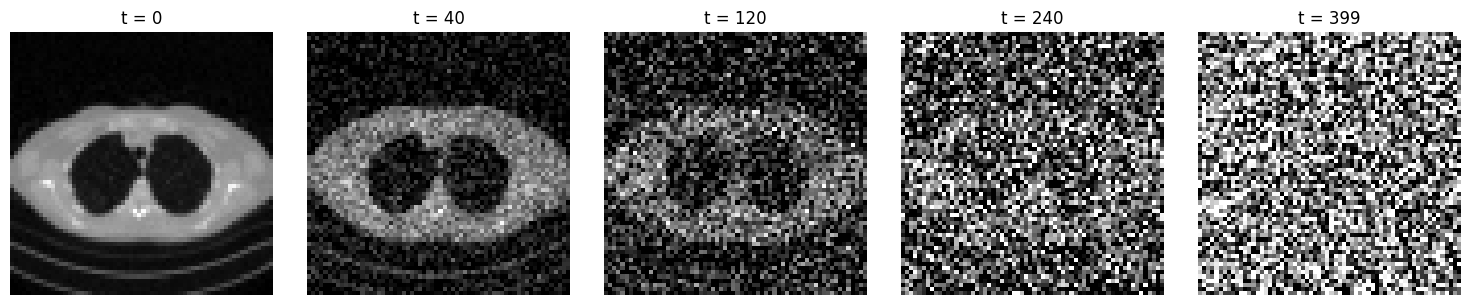

In [2]:
def make_beta_schedule(num_steps):
    return cosine_beta_schedule(num_steps)


num_diffusion_steps = 400
betas = make_beta_schedule(num_diffusion_steps)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

x0 = test_dataset[0].unsqueeze(0)
steps_to_show = [0, 40, 120, 240, 399]

fig, axes = plt.subplots(1, len(steps_to_show), figsize=(15, 3))
for ax, step in zip(axes, steps_to_show):
    t = torch.tensor([step], dtype=torch.long)
    noise = torch.randn_like(x0)
    x_t = extract(alpha_bars.sqrt(), t, x0.shape) * x0 + extract((1 - alpha_bars).sqrt(), t, x0.shape) * noise
    ax.imshow(denormalize_to_01(x_t).squeeze(), cmap='gray')
    ax.set_title(f't = {step}')
    ax.axis('off')
plt.tight_layout()
plt.show()


---
## 3 — Architettura del modello: DiffusionUNet

Il modello $\epsilon_\theta(x_t, t)$ che impara a predire il rumore è una **U-Net condizionata sul timestep**. A differenza della U-Net classica per segmentazione:

- **Time embedding** — Il timestep $t$ viene codificato tramite embedding sinusoidali (simili a quelli dei Transformer) e proiettato in un vettore di dimensione `time_dim=256`, che viene sommato alle feature map a ogni livello della rete.
- **Attention layers** — Ai livelli `attn_levels=(1, 2)` vengono inseriti blocchi di self-attention, che permettono al modello di catturare dipendenze globali nell'immagine.
- **Architettura** — 3 livelli di risoluzione con moltiplicatori di canali `(1, 2, 4)`, ovvero $64 \to 128 \to 256$ canali. L'encoder riduce la risoluzione spaziale, il decoder la ripristina con skip connections.

Rispetto ad altri generativi:
- Nelle **GAN**, il generatore mappa direttamente rumore → immagine (non riceve timestep).
- Nei **VAE**, il decoder riceve un vettore latente $z$ (non un'immagine rumorosa).
- Nei **modelli di diffusione**, la U-Net riceve l'immagine rumorosa $x_t$ **e** il timestep $t$, imparando a stimare il rumore $\epsilon$ per quel livello specifico di corruzione.

**Output atteso:** stampa dell'architettura della rete e del numero totale di parametri.


In [3]:
model = DiffusionUNet(
    in_ch=1,
    base_ch=64,
    channel_mults=(1, 2, 4),
    time_dim=256,
    dropout=0.05,
    attn_levels=(1, 2),
)
num_params = sum(param.numel() for param in model.parameters())
print(model)
print(f'Trainable parameters: {num_params / 1e6:.2f}M')

DiffusionUNet(
  (init): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_mlp): Sequential(
    (0): Linear(in_features=256, out_features=1024, bias=True)
    (1): SiLU()
    (2): Linear(in_features=1024, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): ModuleList(
      (0-1): 2 x ResBlock(
        (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
        (act1): SiLU()
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (time_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=256, out_features=64, bias=True)
        )
        (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
        (act2): SiLU()
        (dropout): Dropout(p=0.05, inplace=False)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (skip): Identity()
      )
      (2): Identity()
    )
    (1): ModuleList(
      (0): ResBlock(
        (norm1): GroupNorm(32, 64, eps=1e-05

---
## 4 — Configurazione del training e gestione dei checkpoint

Questa cella prepara tutto il necessario per il training del DDPM:

### Iperparametri
| Parametro | Valore | Descrizione |
| :--- | :--- | :--- |
| `target_epochs` | 60 | Numero totale di epoche |
| `learning_rate` | $2 \times 10^{-4}$ | Learning rate per AdamW |
| `weight_decay` | $1 \times 10^{-4}$ | Regolarizzazione L2 |
| `ema_decay` | 0.9995 | Decay per l'Exponential Moving Average |
| `grad_clip` | 1.0 | Gradient clipping per stabilità |

### Componenti chiave

- **EMA (Exponential Moving Average):** Mantiene una media mobile esponenziale dei pesi del modello. I pesi EMA producono campioni di qualità superiore rispetto ai pesi grezzi, perché smussano le oscillazioni del training. Questa tecnica è standard nei modelli di diffusione ed è una delle ragioni per cui producono risultati più stabili delle GAN.

- **Mixed precision (AMP):** Su GPU CUDA, il training usa `float16` per velocizzare i calcoli e ridurre l'uso di memoria, con `GradScaler` per evitare underflow nei gradienti.

- **Cosine Annealing LR:** Il learning rate decresce seguendo un coseno, partendo dal valore iniziale e arrivando vicino a zero alla fine del training.

### Checkpoint management
Il sistema di checkpoint supporta tre scenari:
1. **Checkpoint completo** (`.ckpt`): ripristina modello, EMA, optimizer, scheduler e history — permette di riprendere il training esattamente da dove si era interrotto.
2. **Solo pesi EMA** (`.pth`): se il training è già completato, carica i pesi migliori e salta direttamente al sampling.
3. **Nessun file**: parte da zero.

**Output atteso:** un messaggio che indica se il training riparte da un checkpoint, da pesi esistenti, o da zero.


In [4]:
torch.manual_seed(0)

target_epochs = 60
learning_rate = 2e-4
weight_decay = 1e-4
ema_decay = 0.9995
grad_clip = 1.0
force_restart = False

model = DiffusionUNet(
    in_ch=1,
    base_ch=64,
    channel_mults=(1, 2, 4),
    time_dim=256,
    dropout=0.05,
    attn_levels=(1, 2),
).to(device)
ema = EMA(model, decay=ema_decay)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=target_epochs)
scaler = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))
autocast_device = 'cuda' if device == 'cuda' else 'cpu'

history = []
start_epoch = 0
best_loss = float('inf')
weights_path = weights_dir / 'DDPMDenoiser.pth'
raw_weights_path = weights_dir / 'DDPMDenoiser_raw.pth'
checkpoint_path = weights_dir / 'DDPMDenoiser.ckpt'

if checkpoint_path.exists() and not force_restart:
    try:
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint['model'])
        ema.load_state_dict(checkpoint['ema'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        scheduler.load_state_dict(checkpoint['scheduler'])
        scaler.load_state_dict(checkpoint['scaler'])
        for state in optimizer.state.values():
            for key, value in state.items():
                if isinstance(value, torch.Tensor):
                    state[key] = value.to(device)
        history = checkpoint.get('history', [])
        start_epoch = checkpoint.get('epoch', -1) + 1
        best_loss = checkpoint.get('best_loss', float('inf'))
        print(f'Resuming diffusion training from epoch {start_epoch + 1}.')
    except Exception as exc:
        print(f'Ignoring incompatible checkpoint: {exc}')
        start_epoch = 0
        history = []
        best_loss = float('inf')
elif weights_path.exists() and not force_restart:
    try:
        ema_state = torch.load(weights_path, map_location='cpu')
        model.load_state_dict(ema_state)
        ema.shadow.load_state_dict(ema_state)
        start_epoch = target_epochs
        history = []
        print(f'Found existing EMA weights at {weights_path}. Skipping training.')
    except Exception as exc:
        print(f'Ignoring incompatible EMA weights: {exc}')
        start_epoch = 0
        history = []
        best_loss = float('inf')
else:
    print('Starting diffusion training from scratch.')



/var/folders/s0/zl6whyxd2pz_4gm1qdjxbczr0000gn/T/ipykernel_56772/5329716.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))


Resuming diffusion training from epoch 4.


---
## 5 — Training loop del DDPM

Questa è la cella principale del notebook: il **ciclo di addestramento** del modello di diffusione.

### Come funziona il training del DDPM

A differenza delle GAN (dove si alternano aggiornamenti di generatore e discriminatore) e dei VAE (dove si ottimizza l'ELBO), il training del DDPM è sorprendentemente semplice:

Per ogni batch:
1. Si campiona un **timestep casuale** $t$ per ogni immagine del batch.
2. Si genera **rumore gaussiano** $\epsilon \sim \mathcal{N}(0, I)$.
3. Si crea l'immagine corrotta $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon$.
4. Il modello predice il rumore: $\hat{\epsilon} = \epsilon_\theta(x_t, t)$.
5. La **loss è semplicemente MSE** tra il rumore vero e quello predetto: $\mathcal{L} = \|\epsilon - \hat{\epsilon}\|^2$.

### Dettagli implementativi

- **Gradient clipping** a 1.0 per evitare esplosioni nei gradienti.
- **EMA update** dopo ogni step: i pesi shadow vengono aggiornati come $\theta_{\text{ema}} \leftarrow \lambda \cdot \theta_{\text{ema}} + (1-\lambda) \cdot \theta$.
- **Checkpoint salvataggio** ad ogni epoca; i pesi migliori (loss più bassa) vengono salvati separatamente.
- Alla fine del training, viene caricato il modello con i **pesi EMA migliori** in modalità evaluation per il sampling.

### Perché il training è più stabile rispetto alle GAN?

- Non c'è un **avversario** (discriminatore) — il training è una semplice regressione.
- Non c'è rischio di **mode collapse**: il rumore gaussiano copre uniformemente tutto lo spazio dei dati.
- La loss **converge monotonicamente**, senza le oscillazioni tipiche del training GAN.

**Output atteso:** barre di progresso per ogni epoca con loss corrente e media; al termine, un grafico della loss di training nel tempo e il modello caricato con i pesi EMA migliori pronto per il sampling.


DDPM epoch 4/60:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 5/60:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 6/60:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 7/60:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 8/60:   0%|          | 0/414 [00:00<?, ?it/s]

...

DDPM epoch 56/60:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 57/60:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 58/60:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 59/60:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 60/60:   0%|          | 0/414 [00:00<?, ?it/s]

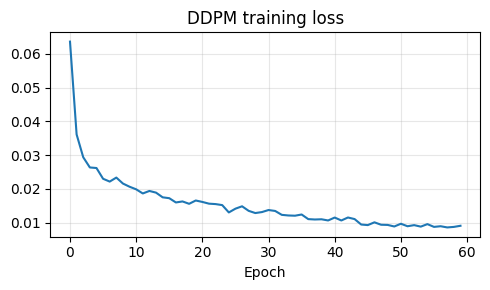

In [5]:
for epoch in range(start_epoch, target_epochs):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'DDPM epoch {epoch + 1}/{target_epochs}', leave=True)

    for step, x0_batch in enumerate(progress_bar, start=1):
        x0_batch = x0_batch.to(device, non_blocking=(device == 'cuda'))
        t = torch.randint(0, num_diffusion_steps, (x0_batch.shape[0],), device=device)
        noise = torch.randn_like(x0_batch)
        x_t = extract(alpha_bars.sqrt(), t, x0_batch.shape) * x0_batch + extract((1 - alpha_bars).sqrt(), t, x0_batch.shape) * noise

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=autocast_device, dtype=torch.float16, enabled=(device == 'cuda')):
            noise_pred = model(x_t, t)
            loss = F.mse_loss(noise_pred, noise)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f'{loss.item():.5f}', avg=f'{epoch_loss / step:.5f}')

    epoch_loss /= len(train_loader)
    history.append(epoch_loss)
    scheduler.step()

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), raw_weights_path)
        torch.save(ema.shadow.state_dict(), weights_path)

    checkpoint = {
        'epoch': epoch,
        'model': model.state_dict(),
        'ema': ema.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'history': history,
        'best_loss': best_loss,
        'config': {
            'target_epochs': target_epochs,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay,
            'ema_decay': ema_decay,
            'grad_clip': grad_clip,
            'num_diffusion_steps': num_diffusion_steps,
        },
    }
    torch.save(checkpoint, checkpoint_path)

if not weights_path.exists():
    torch.save(ema.shadow.state_dict(), weights_path)

sample_model = DiffusionUNet(
    in_ch=1,
    base_ch=64,
    channel_mults=(1, 2, 4),
    time_dim=256,
    dropout=0.05,
    attn_levels=(1, 2),
).to(device)
sample_model.load_state_dict(torch.load(weights_path, map_location='cpu'))
sample_model.eval()

if history:
    plt.figure(figsize=(5, 3))
    plt.plot(history)
    plt.title('DDPM training loss')
    plt.xlabel('Epoch')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()